In [52]:
## import Modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [53]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
#!/bin/bas
!kaggle datasets download ejlok1/toronto-emotional-speech-set-tess

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 428M/428M [00:01<00:00, 240MB/s]



In [54]:
!unzip toronto-emotional-speech-set-tess.zip

Archive:  toronto-emotional-speech-set-tess.zip
replace TESS Toronto emotional speech set data/OAF_Fear/OAF_back_fear.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [47]:
base_path= "/content/TESS Toronto emotional speech set data"
files_name= os.listdir(base_path)
paths=[]
labels=[]
for file_name in files_name:
  temp=os.path.join(base_path, file_name)
  for file in os.listdir(temp):
    path= os.path.join(temp, file)
    paths.append(path)
    label= file.split('_')[-1]
    labels.append(label.split('.')[0])


In [48]:
paths[:5]

['/content/TESS Toronto emotional speech set data/YAF_angry/YAF_sour_angry.wav',
 '/content/TESS Toronto emotional speech set data/YAF_angry/YAF_ripe_angry.wav',
 '/content/TESS Toronto emotional speech set data/YAF_angry/YAF_pike_angry.wav',
 '/content/TESS Toronto emotional speech set data/YAF_angry/YAF_calm_angry.wav',
 '/content/TESS Toronto emotional speech set data/YAF_angry/YAF_pearl_angry.wav']

In [49]:
labels[:5]

['angry', 'angry', 'angry', 'angry', 'angry']

In [50]:
## creating the dataframe
df= pd.DataFrame()
df['speech']= paths
df['labels']= labels
df.tail()

,speech,labels
2795,/content/TESS Toronto emotional speech set dat...,angry
2796,/content/TESS Toronto emotional speech set dat...,angry
2797,/content/TESS Toronto emotional speech set dat...,angry
2798,/content/TESS Toronto emotional speech set dat...,angry
2799,/content/TESS Toronto emotional speech set dat...,angry


In [51]:
df['labels'].value_counts()

,count
labels,
angry,400
neutral,400
ps,400
happy,400
sad,400
fear,400
disgust,400


## EDA

<Axes: xlabel='count', ylabel='labels'>

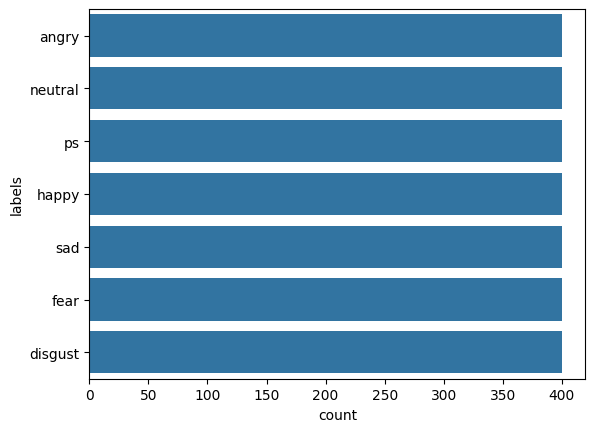

In [10]:
sns.countplot(df['labels'])

#### waveplot and spectogram

In [14]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

def waveplot(data, sr, emotion):
    plt.figure(figsize=(10, 4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)  # updated function
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def spectrogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))

    plt.figure(figsize=(10, 4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

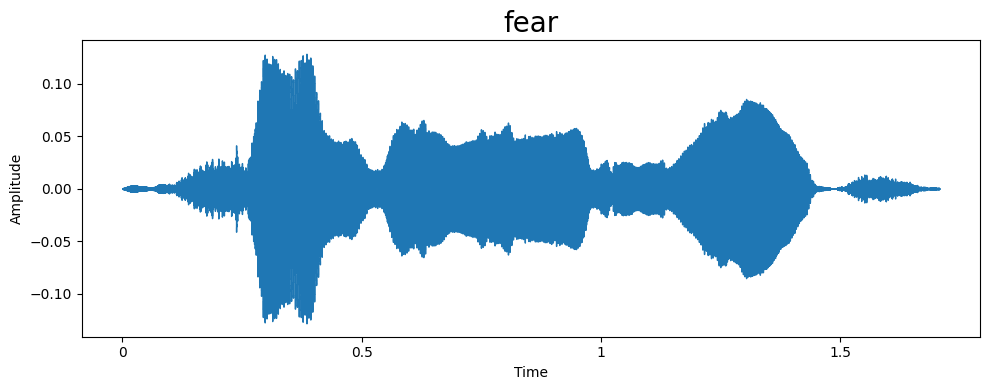

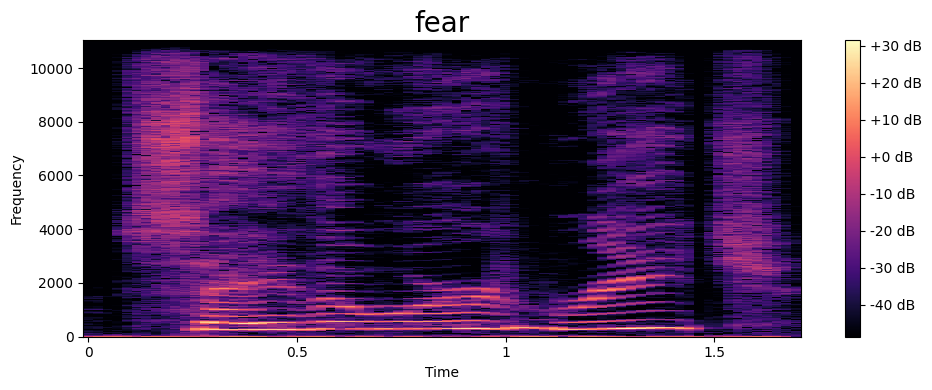

In [16]:
emotion='fear'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='angry'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

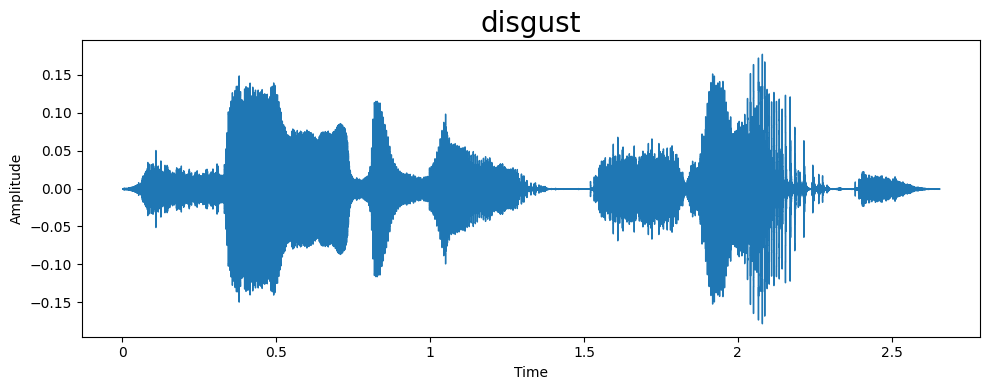

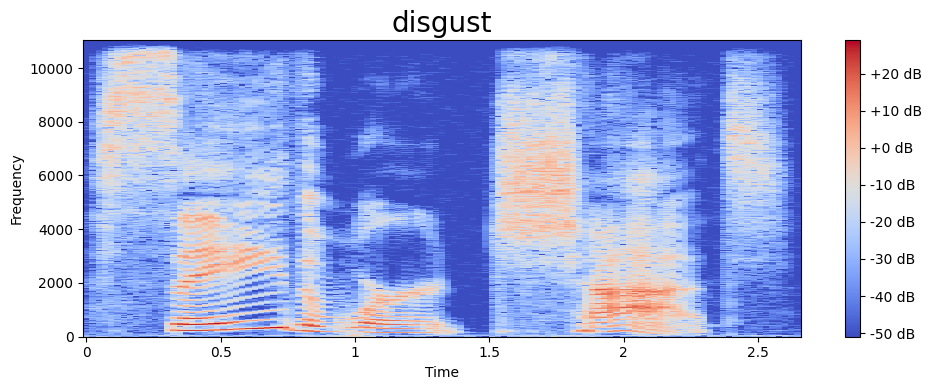

In [17]:
emotion='disgust'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='happy'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='sad'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
emotion='neutral'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

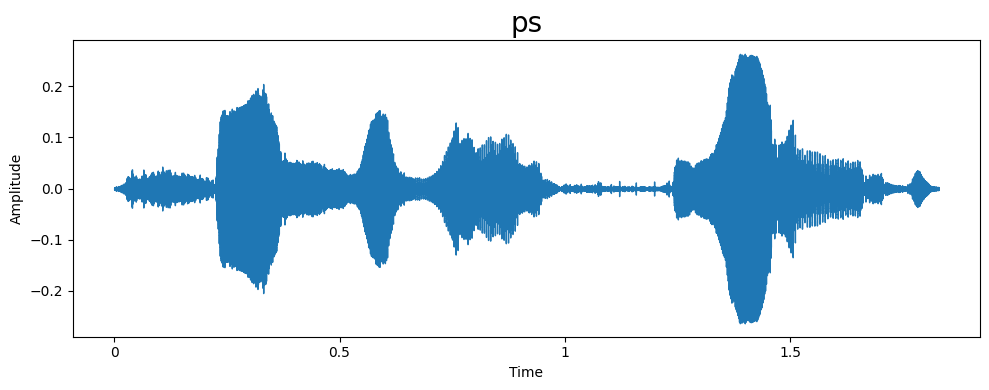

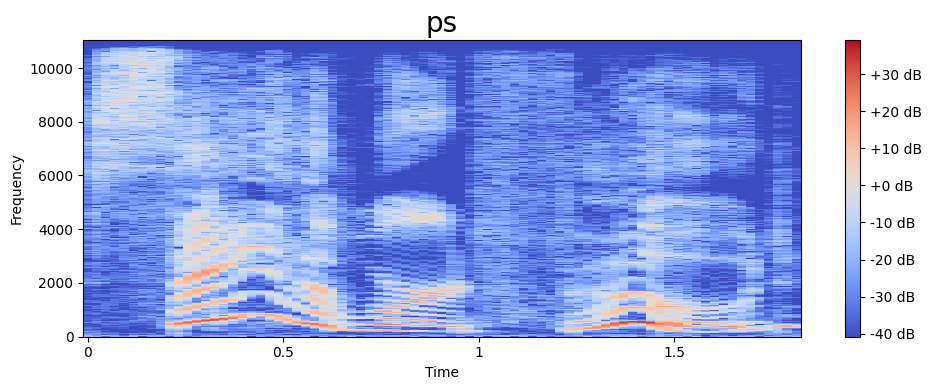

In [18]:
emotion='ps'
path= np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate= librosa.load(path)

waveplot(data, sampling_rate, emotion)
spectrogram(data, sampling_rate, emotion)
Audio(path)

## Feature Extraction

In [19]:
def extract_mfcc(filename):
    # Load audio file
    y, sr = librosa.load(filename, duration=3, offset=0.5)

    # Extract MFCC features
    mfcc = np.mean(
        librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T,
        axis=0
    )

    return mfcc

In [20]:
X_mfcc= df['speech'].apply(lambda x: extract_mfcc(x))

In [21]:
X_mfcc

,speech
0,"[-350.60492, 65.69591, -6.014192, 1.1447572, -..."
1,"[-366.62015, 81.051414, -2.6290882, 15.623847,..."
2,"[-335.85297, 44.492443, -14.665875, 18.491714,..."
3,"[-334.913, 80.739006, -17.77005, -4.618028, -2..."
4,"[-317.90005, 71.726906, -4.753657, -0.3481185,..."
...,...
2795,"[-414.75995, 61.79036, -4.121467, 0.11835582, ..."
2796,"[-416.87918, 103.68762, 11.0172, -33.429592, -..."
2797,"[-382.7069, 41.59465, 6.4546814, -7.075049, -1..."
2798,"[-434.54526, 82.24351, 17.994448, -10.922421, ..."


In [27]:
X= [x for x in X_mfcc]
X= np.array(X)
X.shape

(2800, 40)

In [28]:
X

array([[-3.5060492e+02,  6.5695908e+01, -6.0141921e+00, ...,
         5.4138989e+00,  6.7310791e+00,  7.2020488e+00],
       [-3.6662015e+02,  8.1051414e+01, -2.6290882e+00, ...,
         6.5063772e+00,  7.0663161e+00,  3.0519111e+00],
       [-3.3585297e+02,  4.4492443e+01, -1.4665875e+01, ...,
         5.0044098e+00,  4.9715734e-01,  4.5187086e-01],
       ...,
       [-3.8270691e+02,  4.1594650e+01,  6.4546814e+00, ...,
         1.9317298e+00, -7.1043167e+00,  1.6700212e+00],
       [-4.3454526e+02,  8.2243507e+01,  1.7994448e+01, ...,
         9.4150095e+00, -2.4799547e-01,  3.7969918e+00],
       [-4.2840350e+02,  6.5692123e+01,  5.5648232e+00, ...,
         1.0271579e+01,  4.2470574e+00,  3.4324038e+00]], dtype=float32)

In [29]:
X= np.expand_dims(X, -1)
X.shape

(2800, 40, 1)

In [31]:
from sklearn.preprocessing import OneHotEncoder
enc= OneHotEncoder()
y= enc.fit_transform(df[['labels']])

In [39]:
y=y.toarray()

### creating lstm model

In [36]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model= Sequential([
    LSTM(123, return_sequences=False, input_shape=(40,1)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'] )

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 123)            │        61,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,747 (280.26 KB)

 Trainable params: 71,747 (280.26 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
### train the model

history= model.fit(X, y, validation_split=0.2, epochs=100, batch_size=512, shuffle= True )

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.2161 - loss: 1.8785 - val_accuracy: 0.0036 - val_loss: 2.0296
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3562 - loss: 1.7066 - val_accuracy: 0.0857 - val_loss: 2.0396
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4429 - loss: 1.5563 - val_accuracy: 0.1554 - val_loss: 1.9965
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4862 - loss: 1.3924 - val_accuracy: 0.0857 - val_loss: 2.0547
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5442 - loss: 1.2432 - val_accuracy: 0.0804 - val_loss: 2.0908
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6121 - loss: 1.0764 - val_accuracy: 0.0821 - val_loss: 2.1319
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6781 - loss: 0.9347 - val_accuracy: 0.2018 - val_loss: 1.8799
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7312 - loss: 0.7555 - val_accuracy: 0.4054 - val_loss

### plot the results

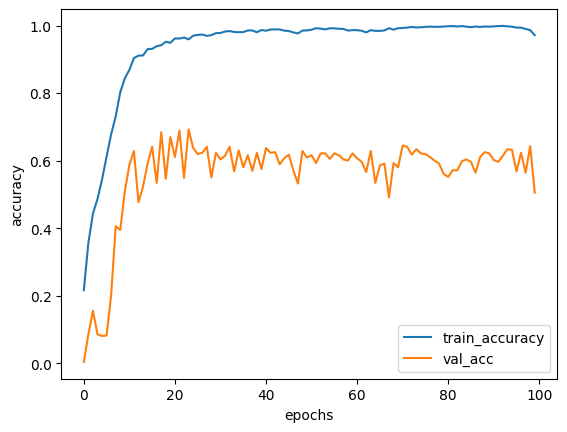

In [45]:
epochs= list(range(100))
acc= history.history['accuracy']
val_acc= history.history['val_accuracy']

plt.plot(epochs, acc, label='train_accuracy')
plt.plot(epochs, val_acc, label=['val_acc'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

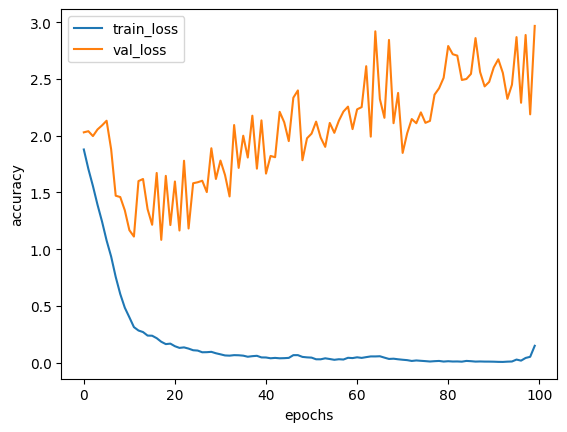

In [46]:
 epochs= list(range(100))
acc= history.history['loss']
val_acc= history.history['val_loss']

plt.plot(epochs, acc, label='train_loss')
plt.plot(epochs, val_acc, label=['val_loss'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()